# Boiling Point Prediction with Curated RDKit Descriptors

A fresh start on the same problem, independent of `Boiling_Point_Predicter.ipynb`, with two changes:

1. **Features.** Curated RDKit descriptors, each chosen for a physical reason it should affect boiling point, replace the original 12. Those were PubChem properties plus character counts from SMILES strings, and they couldn't tell isomers apart.
2. **Evaluation.** Repeated cross-validation, stratified by chemical family, with hyperparameters tuned inside each training fold (nested CV). The original project's single random split gave a test RMSE of 26 K while cross-validation said 36 K: the test set was unusually easy.

The heavy computation runs in `scripts/run_feature_study.py` (~3 minutes on 9 cores); this notebook loads its results.

In [1]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

from boiling_point import descriptors, features, validation  # boiling_point first: loads xgboost before torch

import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from run_feature_study import EXCLUDED, OUT_DIR, load_study_data

df, feature_sets = load_study_data()
predictions = pd.read_csv(f"{OUT_DIR}/predictions.csv")
metrics = pd.read_csv(f"{OUT_DIR}/fold_metrics.csv")
fold_summary = pd.read_csv(f"{OUT_DIR}/fold_summary.csv")

## Data

The 1,588 literature compounds, minus two whose boiling points look like data-entry errors. Both run ~90–100 K low against independent sources (found in the original notebook's error analysis). Their true values are uncertain (one source is a retail site), so they are excluded rather than 'corrected'.

In [2]:
from boiling_point import data
raw = data.build_modelling_table(
    data.load_literature_data("compound_boiling_points_from_literature.xlsx"),
    data.load_pubchem_data("compound_property_from_PubChem.csv"))
excluded = raw[raw["cmpdname"].isin(EXCLUDED)][["cmpdname", "boiling_point_kelvin"]]
excluded["cross-referenced value (K)"] = excluded["cmpdname"].map(
    {"2,6-Nonadien-1-ol": 469.15, "N-Methyldodecylamine": 473.15})
print(f"{len(raw)} literature compounds, {len(excluded)} excluded -> {len(df)} used")
excluded

1588 literature compounds, 2 excluded -> 1586 used


,cmpdname,boiling_point_kelvin,cross-referenced value (K)
538,"2,6-Nonadien-1-ol",369.65,469.15
680,N-Methyldodecylamine,382.15,473.15


## Chemical families

Each compound gets one primary family from RDKit substructure patterns (`src/boiling_point/families.py`). Patterns are checked in priority order, roughly by the strength of the intermolecular force the group adds: carboxylic acid > amide > alcohol > amine > ester > ketone/aldehyde > ether > nitrile/nitro > sulfur > halide > aromatic > alkene/alkyne > alkane.

In [3]:
(df.groupby("family")["boiling_point_kelvin"]
 .agg(compounds="count", median="median", min="min", max="max").round(0)
 .sort_values("compounds", ascending=False))

,compounds,median,min,max
family,,,,
alcohol/phenol,525,479.0,328.0,1315.0
alkane,495,458.0,112.0,1343.0
alkene/alkyne,405,398.0,169.0,1168.0
amine,158,411.0,267.0,1059.0
other,3,253.0,112.0,368.0


**This dataset is narrower than it looks.** It contains only carbon, hydrogen, nitrogen, oxygen and (in two compounds) boron, and **every compound is acyclic**. There are no rings, aromatics, acids, esters, ketones, halogens or sulfur: just four families of chain molecules. The 59 compounds with an ether group all also have an OH group, so they count as alcohols (glycol ethers). The 3 'other' compounds (two boranes and deuterated methane) are too few to appear in every fold, so they're grouped with the largest family *for splitting only*.

## Curated descriptors

A liquid boils when its molecules overcome the forces holding them together, so each descriptor is here for the force it tracks (`src/boiling_point/descriptors.py`):

In [4]:
pd.DataFrame([{"group": group, "descriptors": ", ".join(names)}
              for group, names in descriptors.DESCRIPTOR_GROUPS.items()])

,group,descriptors
0,size / polarizability (dispersion forces),"MolWt, HeavyAtomCount, MolMR, LabuteASA"
1,branching / shape (contact area),"WienerIndex, Kappa1, Kappa2, Kappa3, Chi0v, Ch..."
2,polarity / hydrogen bonding,"TPSA, MolLogP, NumHDonors, NumHAcceptors, fr_A..."
3,rings / flexibility / unsaturation,"NumAromaticRings, RingCount, FractionCSP3, Num..."
4,composition,"n_C, n_O, n_N, n_S, n_F, n_Cl, n_Br, n_I, n_B"


In [5]:
curated = feature_sets["curated"]
constant = curated.columns[curated.nunique() <= 1].tolist()
varying = curated.drop(columns=constant)
kept = varying.columns[descriptors.DropCorrelated(0.95).fit(varying).keep_].tolist()
old = feature_sets["old 12"]
ties = lambda X: X[X.duplicated(keep=False)].groupby(list(X.columns)).ngroups
pd.Series({
    "curated descriptors": curated.shape[1],
    "constant on this data (dropped)": f"{len(constant)}: " + ", ".join(constant),
    "left after the correlation filter (fitted on all data here; per training fold in the models)": f"{len(kept)}: " + ", ".join(kept),
    "isomer groups with identical features: old 12": ties(old),
    "isomer groups with identical features: curated": ties(curated),
}).to_frame("")

,
curated descriptors,43
constant on this data (dropped),"15: fr_Ar_OH, fr_COO, fr_amide, fr_ester, fr_k..."
left after the correlation filter (fitted on all data here; per training fold in the models),"18: MolWt, WienerIndex, Kappa2, Kappa3, Balaba..."
isomer groups with identical features: old 12,224
isomer groups with identical features: curated,71


- **Many curated descriptors are constant on this data,** for the reason above (no rings, acids, halogens and so on). The model pipelines drop them on each training fold (`VarianceThreshold`).
- **Ridge and the MLP also drop near-duplicates** (`DropCorrelated`, |r| > 0.95), e.g. `MolWt`, `MolMR`, `LabuteASA` and `Chi0v` all measure size. XGBoost gets all non-constant descriptors, since trees cope with redundancy.
- **Isomer ties mostly disappear.** Compounds with identical feature values drop from 224 groups to 71: the branching and shape indices (Wiener index, Kappa, Balaban J) separate most isomers the old features couldn't. 64 of the remaining 71 are pure stereoisomers (e.g. cis/trans), which these descriptors don't distinguish; the other 7 are close positional isomers such as 2-methyl-3-hexanol vs 3-methyl-2-hexanol.

## Evaluation protocol

- **Outer loop:** 5-fold cross-validation stratified by family, repeated 3 times with different shuffles, giving 15 outer folds. Every compound is predicted 3 times, each time by a model that never saw it.
- **Inner loop:** inside each outer training fold, a randomized search (25 samples, 3-fold stratified CV) picks the hyperparameters from the original project's grids. The outer test fold never influences tuning.
- **Models:**
  - Ridge;
  - XGBoost;
  - an MLP;
  - their **ensemble** (the average of the three tuned members);
  - for the family comparison, XGBoost trained separately per family.
- **Feature sets:**
  - the **old 12**;
  - **curated**;
  - **curated + family** (the family as a one-hot input).

The 15 fold models only *measure*; they are discarded. Each recipe (feature set + model + tuning procedure) gets 15 honest scores. The final model is the best recipe re-tuned and fitted on all the data, and its expected accuracy is the recipe's nested-CV score.

## Result 1: the curated features don't beat the old 12 overall

In [6]:
MODELS = ["ridge", "xgboost", "mlp", "ensemble"]
FEATURE_SETS = ["old 12", "curated", "curated + family"]
table = (metrics[metrics["model"].isin(MODELS)]
         .groupby(["feature_set", "model"])[["rmse", "mae", "r2", "rmse_hard"]]
         .agg(["mean", "std"]))
table = table.round({c: 3 if c[0] == "r2" else 1 for c in table.columns})
table.columns = [f"{metric} {stat}" for metric, stat in table.columns]
gap = (fold_summary[fold_summary["model"].isin(MODELS)]
       .assign(gap=lambda d: d["test_rmse"] - d["train_rmse"])
       .groupby(["feature_set", "model"])[["train_rmse", "test_rmse", "gap"]].mean().round(1))
table.join(gap).loc[FEATURE_SETS]

rmse mean  rmse std  mae mean  mae std  r2 mean  \
feature_set      model                                                       
old 12           ensemble       32.0       2.6      17.3      1.0    0.934   
                 mlp            31.8       3.0      16.3      1.1    0.935   
                 ridge          39.4       2.3      23.5      1.1    0.901   
                 xgboost        34.3       3.9      17.0      1.2    0.925   
curated          ensemble       34.4       3.8      17.5      1.4    0.925   
                 mlp            36.6       5.4      18.0      2.0    0.913   
                 ridge          37.5       3.1      21.2      1.3    0.910   
                 xgboost        37.8       4.3      17.9      1.4    0.909   
curated + family ensemble       35.3       3.5      17.8      1.1    0.921   
                 mlp            38.9       5.6      18.9      1.3    0.903   
                 ridge          37.3       3.1      20.6      1.3    0.911   
                 xgboost        37.8       4.4      17.9      1.4    0.909   

                           r2 std  rmse_hard mean  rmse_hard std  train_rmse  \
feature_set      model                                                         
old 12           ensemble   0.012            64.0            6.3        24.9   
                 mlp        0.015            62.7            7.0        24.5   
                 ridge      0.016            78.9            8.2        38.7   
                 xgboost    0.014            69.7           10.9        20.0   
curated          ensemble   0.013            70.5            8.9        24.4   
                 mlp        0.022            73.6           12.4        25.7   
                 ridge      0.011            76.5            7.9        35.9   
                 xgboost    0.018            78.8           13.1        18.6   
curated + family ensemble   0.011            73.1            8.5        25.4   
                 mlp        0.023            80.1           12.7        28.1   
                 ridge      0.012            76.4            8.2        35.5   
                 xgboost    0.017            78.9           13.4        18.9   

                           test_rmse   gap  
feature_set      model                      
old 12           ensemble       32.0   7.1  
                 mlp            31.8   7.3  
                 ridge          39.4   0.7  
                 xgboost        34.3  14.2  
curated          ensemble       34.4  10.0  
                 mlp            36.6  11.0  
                 ridge          37.5   1.6  
                 xgboost        37.8  19.2  
curated + family ensemble       35.3   9.9  
                 mlp            38.9  10.8  
                 ridge          37.3   1.8  
                 xgboost        37.8  18.9

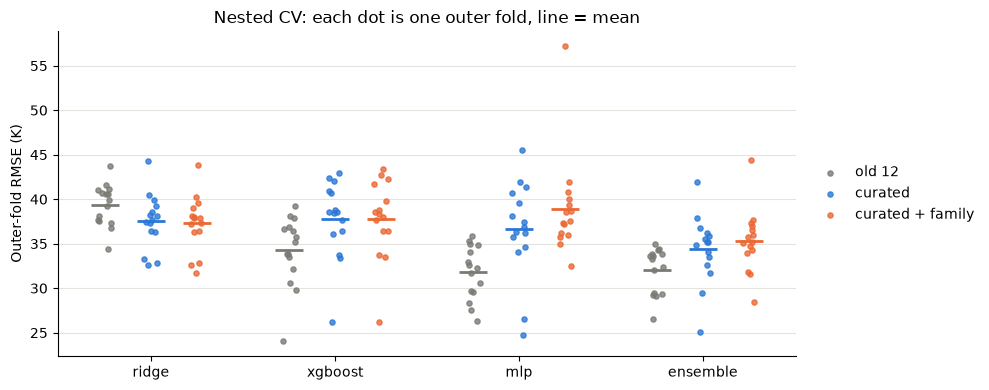

In [7]:
# Per-fold RMSE for each recipe: every dot is one outer fold (15 per recipe)
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"old 12": "#7a7a75", "curated": "#2a78d6", "curated + family": "#eb6834"}
positions = []
for i, model in enumerate(MODELS):
    for j, fs in enumerate(FEATURE_SETS):
        x = i * 4 + j
        vals = metrics[(metrics["model"] == model) & (metrics["feature_set"] == fs)]["rmse"]
        ax.scatter(np.full(len(vals), x) + np.random.default_rng(x).uniform(-0.15, 0.15, len(vals)),
                   vals, s=14, color=colors[fs], alpha=0.8, label=fs if i == 0 else None)
        ax.hlines(vals.mean(), x - 0.3, x + 0.3, color=colors[fs], linewidth=2)
ax.set_xticks([i * 4 + 1 for i in range(len(MODELS))], MODELS)
ax.set_ylabel("Outer-fold RMSE (K)")
ax.set_title("Nested CV: each dot is one outer fold, line = mean")
ax.grid(True, axis="y", color="#e4e3dd", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.show()

In [8]:
# Paired comparison on the same outer folds: curated minus old 12
wide = metrics[metrics["model"].isin(MODELS)].pivot_table(
    index=["model", "repeat", "fold"], columns="feature_set", values="rmse")
diff = (wide["curated"] - wide["old 12"]).groupby("model")
pd.DataFrame({"mean change (K)": diff.mean().round(1), "std (K)": diff.std().round(1),
              "folds where curated is better": diff.apply(lambda d: f"{(d < 0).sum()}/{len(d)}")})

,mean change (K),std (K),folds where curated is better
model,,,
ensemble,2.4,2.1,1/15
mlp,4.9,3.6,2/15
ridge,-1.8,2.0,12/15
xgboost,3.5,2.0,0/15


- **By RMSE, the old 12 features win for three of four models.**
  - ensemble: 32.0 vs 34.4 K;
  - MLP: 31.8 vs 36.6 K;
  - XGBoost: 34.3 vs 37.8 K.
  
  Fold by fold the curated set rarely wins (1, 2 and 0 of 15 folds). **Ridge is the exception:** curated is better (37.5 vs 39.4 K; 12/15 folds by RMSE and 15/15 by MAE). A linear model gains from descriptors that already encode the physics.
- **By MAE, the ensemble is a tie** (17.5 vs 17.3 K; curated better in 7/15 folds). XGBoost is slightly but consistently worse with curated features (+0.9 K, 14/15 folds). RMSE squares errors, so it's dominated by a few large ones; MAE isn't. When RMSE differs but MAE doesn't, a few compounds are driving the difference.
- **Overfitting:** the train-vs-validation gaps are similar for both feature sets. XGBoost has the largest gap everywhere (14–19 K), Ridge the smallest (1–2 K), and averaging in the ensemble keeps the gap at 7–10 K.

### Where does the difference come from?

In [9]:
# Where does the RMSE gap between curated and old-12 (ensemble) come from?
# Diagnostic only -- not used to choose anything.
ens = predictions[predictions["model"] == "ensemble"].pivot_table(
    index=["repeat", "row"], columns="feature_set", values="y_pred").reset_index()
ens = ens.merge(df[["cmpdname", "family", "boiling_point_kelvin"]], left_on="row", right_index=True)
per_compound = ens.groupby("row").agg(
    compound=("cmpdname", "first"), family=("family", "first"), boiling_point=("boiling_point_kelvin", "first"),
    error_old=("old 12", "mean"), error_curated=("curated", "mean"))
per_compound["error_old"] -= per_compound["boiling_point"]
per_compound["error_curated"] -= per_compound["boiling_point"]
per_compound["extra_squared_error"] = per_compound["error_curated"] ** 2 - per_compound["error_old"] ** 2
worst = per_compound.sort_values("extra_squared_error", ascending=False)
rest = per_compound.drop(worst.index[:20])
print(f"share of the gap from the 20 compounds where curated loses most: "
      f"{worst['extra_squared_error'].head(20).sum() / per_compound['extra_squared_error'].sum():.0%}")
print(f"RMSE on the other {len(rest)} compounds: old 12 {np.sqrt((rest['error_old'] ** 2).mean()):.1f} K, "
      f"curated {np.sqrt((rest['error_curated'] ** 2).mean()):.1f} K")
print(f"compounds where curated is closer: {(per_compound['error_curated'].abs() < per_compound['error_old'].abs()).mean():.0%}")
worst.head(12).drop(columns="extra_squared_error").round(0)

share of the gap from the 20 compounds where curated loses most: 102%
RMSE on the other 1566 compounds: old 12 28.1 K, curated 28.1 K
compounds where curated is closer: 57%


,compound,family,boiling_point,error_old,error_curated
row,,,,,
997,17-n-Hexadecyltetratriacontane,alkane,1343.0,-214.0,-313.0
1009,Lycopene,alkene/alkyne,1168.0,-170.0,-245.0
654,N-Methyldioctadecylamine,amine,1059.0,-126.0,-190.0
50,Tridodecylamine,amine,721.0,198.0,237.0
376,Didodecylamine,amine,453.0,247.0,272.0
96,Squalane,alkane,693.0,163.0,197.0
591,Tripentaerythritol,alcohol/phenol,1315.0,-170.0,-202.0
1451,2-Methyltritriacontane,alkane,977.0,-41.0,-108.0
631,2-Methyldotriacontane,alkane,954.0,-36.0,-102.0


**Essentially all of the RMSE gap comes from about 20 compounds (1% of the data).** On the other ~1,566 compounds the two feature sets are identical (28.1 K each), and the curated set is closer to the truth for most compounds (57%).

The 20 are extreme molecules where *both* feature sets fail badly:
- giant alkanes such as the C₅₀ 17-n-hexadecyltetratriacontane (listed at 1,343 K), and long methyl-branched alkanes around 950–1,100 K;
- lycopene (1,168 K) and tripentaerythritol (1,315 K);
- a few long-chain amines, including didodecylamine, a C₂₄ amine listed at 453 K. That value is implausibly low; both models predict ~250 K higher.

Molecules this large decompose long before they could boil at atmospheric pressure, so their listed normal boiling points are most likely extrapolated estimates, not measurements. **The model comparison is being decided by the least reliable 1% of the labels.** One plausible reason the curated set does worse on them: shape indices such as the Wiener index grow roughly with the cube of chain length, so giant molecules sit far outside the range of typical compounds. A log transform of those descriptors would be a principled next test.

## Result 2: errors by family

In [10]:
def rmse(g):
    return float(np.sqrt(((g["y_pred"] - g["y_true"]) ** 2).mean()))

per_family = (predictions[predictions["model"].isin(["ensemble", "xgboost"])]
              .groupby(["feature_set", "model", "family"]).apply(rmse, include_groups=False)
              .unstack("family").round(1))
per_family["all"] = (predictions[predictions["model"].isin(["ensemble", "xgboost"])]
                     .groupby(["feature_set", "model"]).apply(rmse, include_groups=False).round(1))
per_family.loc[FEATURE_SETS]

family                     alcohol/phenol  alkane  alkene/alkyne  amine  \
feature_set      model                                                    
old 12           ensemble            35.3    26.8           25.2   47.6   
                 xgboost             39.2    27.6           25.1   52.8   
curated          ensemble            35.1    32.5           26.5   51.6   
                 xgboost             41.2    33.5           27.2   57.8   
curated + family ensemble            34.9    35.0           27.3   51.9   
                 xgboost             41.6    33.7           26.7   57.4   

family                     other   all  
feature_set      model                  
old 12           ensemble   58.7  32.1  
                 xgboost    44.5  34.5  
curated          ensemble   85.1  34.6  
                 xgboost    72.9  38.0  
curated + family ensemble   89.5  35.5  
                 xgboost    77.5  38.1

Amines are the hardest family (~48–52 K RMSE), which makes sense: they're the smallest family (158 compounds) and hydrogen bonding in amines depends on how many N–H bonds there are, which varies a lot. Alkenes/alkynes are the easiest (~25–27 K). The curated set's extra RMSE sits mainly in **alkanes** (32.5 vs 26.8 K), where the giant molecules are.

## Result 3: one global model is the right design

Three ways to use the family: a global model (above), a global model with family as a one-hot input, and separate XGBoost models per family, compared on exactly the same test compounds.

In [11]:
# Global vs per-family XGBoost on exactly the same test compounds (curated features)
cur = predictions[predictions["feature_set"] == "curated"]
keys = ["repeat", "fold", "row"]
pf = cur[cur["model"] == "xgboost_per_family"][keys + ["family", "y_true", "y_pred"]]
glob = cur[cur["model"] == "xgboost"][keys + ["y_pred"]].rename(columns={"y_pred": "y_global"})
both = pf.merge(glob, on=keys)
by_family = both.groupby("family").apply(lambda g: pd.Series({
    "compounds (x3 repeats)": len(g),
    "global XGBoost RMSE": np.sqrt(((g["y_global"] - g["y_true"]) ** 2).mean()),
    "per-family XGBoost RMSE": np.sqrt(((g["y_pred"] - g["y_true"]) ** 2).mean()),
}), include_groups=False).round(1)
by_family

,compounds (x3 repeats),global XGBoost RMSE,per-family XGBoost RMSE
family,,,
alcohol/phenol,1575.0,41.2,44.7
alkane,1485.0,33.5,31.7
alkene/alkyne,1215.0,27.2,31.9
amine,474.0,57.8,61.7


- **Adding the family as an input doesn't help** (ensemble 35.3 vs 34.4 K without it). The curated descriptors already encode the functional groups (OH, NH counts), so the family label adds nothing new.
- **Separate per-family models are worse** for three of the four families (alcohols, alkenes/alkynes, amines). Alkanes are the exception: slightly better RMSE (31.7 vs 33.5 K) and MAE (11.1 vs 12.8 K). A global model shares what all families have in common (size and shape drive boiling point everywhere), and each per-family model has less data to learn from.

## The final model

In [12]:
final = json.load(open(f"{OUT_DIR}/final_model.json"))
winner = metrics[(metrics["feature_set"] == final["feature_set"]) & (metrics["model"] == final["model"])]
print(f"Final recipe: {final['feature_set']} + {final['model']}")
print(f"Expected accuracy (nested CV): RMSE {winner['rmse'].mean():.1f} ± {winner['rmse'].std():.1f} K, "
      f"MAE {winner['mae'].mean():.1f} K, R² {winner['r2'].mean():.3f}")
final["params"]

Final recipe: old 12 + mlp
Expected accuracy (nested CV): RMSE 31.8 ± 3.0 K, MAE 16.3 K, R² 0.935


{'mlp': {'regressor__model__solver': 'adam',
  'regressor__model__learning_rate_init': 0.001,
  'regressor__model__learning_rate': 'constant',
  'regressor__model__hidden_layer_sizes': [100, 50, 20],
  'regressor__model__alpha': 0.01,
  'regressor__model__activation': 'relu'}}

In [13]:
# Stability: how much did the tuned hyperparameters vary across the 15 outer folds?
members = [final["model"]] if final["model"] != "ensemble" else ["ridge", "xgboost", "mlp"]
rows = fold_summary[(fold_summary["feature_set"] == final["feature_set"]) & fold_summary["model"].isin(members)]
chosen = pd.DataFrame([{"model": r.model, **json.loads(r.params)} for r in rows.itertuples()])
{m: {k.split("__")[-1]: g[k].astype(str).value_counts().to_dict()
     for k in g.columns if k != "model" and g[k].notna().any()}
 for m, g in chosen.groupby("model")}

{'mlp': {'solver': {'adam': 15},
  'learning_rate_init': {'0.001': 15},
  'learning_rate': {'constant': 15},
  'hidden_layer_sizes': {'[100, 50]': 9, '[100, 50, 20]': 6},
  'alpha': {'0.0001': 9, '0.01': 6},
  'activation': {'relu': 15}}}

- **The chosen recipe: old 12 features + MLP.** Selection used the planned rule, lowest mean outer-fold RMSE. It is effectively **tied** with the old-12 ensemble (31.8 ± 3.0 vs 32.0 ± 2.6 K); the ensemble is slightly more stable across folds. Picking the best of 12 recipes slightly flatters the winner.
- **Its hyperparameters were stable.** Adam, ReLU and a 0.001 learning rate were chosen in all 15 outer folds. Only the layer sizes and regularisation strength varied between two close options.
- **Expected accuracy: RMSE ≈ 32 ± 3 K and MAE ≈ 16 K per fold.** That sits between the original notebook's single-split test (26 K, an easy test set) and its 5-fold CV (36 K), and it's a far more trustworthy estimate.
- **Saved as** `results/feature_study/final_model.joblib`, tuned and fitted on all 1,586 compounds.

## Conclusions

1. **Honest accuracy is ~32 ± 3 K RMSE (~16 K MAE).** Nested, family-stratified CV removes the single-split luck that produced the original 26 K headline.
2. **Curated RDKit descriptors didn't beat the original 12 features on this data.** They tie on typical compounds (same RMSE on 99% of them; closer on 57%) and help the linear model consistently. They do worse on ~20 giant molecules whose listed boiling points are probably extrapolated estimates. The dataset is narrow: four acyclic families of C/H/N/O. The old features already capture what matters most here (size, OH and N counts), so many chemically motivated descriptors have nothing to add.
3. **One global model is better than per-family models** (worse for 3 of 4 families), and the family as an input adds nothing.
4. **Next levers, in order:**
   1. **Audit or set aside the extreme labels** (≳900 K, and suspicious ones like didodecylamine). They dominate every RMSE comparison.
   2. **Select models by a robust metric** such as MAE, or report both, so 1% of compounds can't decide the winner.
   3. **Log-transform size and shape descriptors** so giant molecules aren't extreme outliers in feature space.
   4. **Test on broader data:** rings, aromatics, halogens and carbonyls. That's where richer descriptors would be expected to matter. The halogenated NIST compounds from the active-learning work are a ready-made start.